# Supply Chain Analytics - Demand Forecasting

## Objective

The objective of this notebook is to develop a time-series forecasting model to predict future daily sales.

Demand forecasting helps businesses improve inventory planning, reduce stock shortages, and optimize supply chain operations.

This notebook begins by preparing the daily sales time series that will be used for forecasting.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv(
    "../data/cleaned/retail_store_inventory_cleaned.csv",
    parse_dates=["Date"])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
daily_sales = (df.groupby("Date")["Units Sold"]
      .sum()
      .reset_index())

daily_sales.head()

,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


## Daily Sales Trend

Before building forecasting models, it is important to visualize the historical demand pattern.

The following plot illustrates how daily sales change over time and provides an initial understanding of trends and fluctuations.

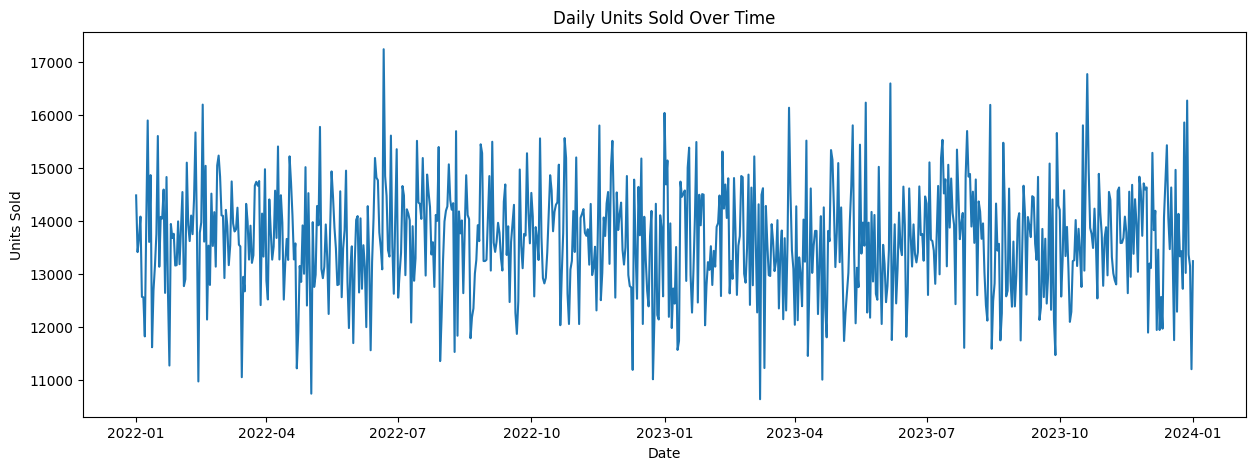

In [5]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"])

plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

## Train-Test Split

To evaluate the forecasting model, the daily sales data is divided into training and testing sets.

Unlike random splitting, time-series data must be split chronologically to preserve the temporal order of observations.

The training set is used to build the forecasting model, while the testing set is used to evaluate its performance on unseen future data.

In [6]:
split_index = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_index]
test = daily_sales.iloc[split_index:]

print("Training Set:", train.shape)
print("Testing Set:", test.shape)

Training Set: (584, 2)
Testing Set: (147, 2)


In [7]:
print("Training Data")
display(train.head())

print("Testing Data")
display(test.head())

Training Data


,Date,Units Sold
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


Testing Data


,Date,Units Sold
584,2023-08-08,13666
585,2023-08-09,13956
586,2023-08-10,13028
587,2023-08-11,12414
588,2023-08-12,12124


## Visualization of Train-Test Split

The following plot shows the chronological separation between the training and testing datasets.

The blue line represents the historical data used for training, while the orange line represents the unseen data reserved for model evaluation.

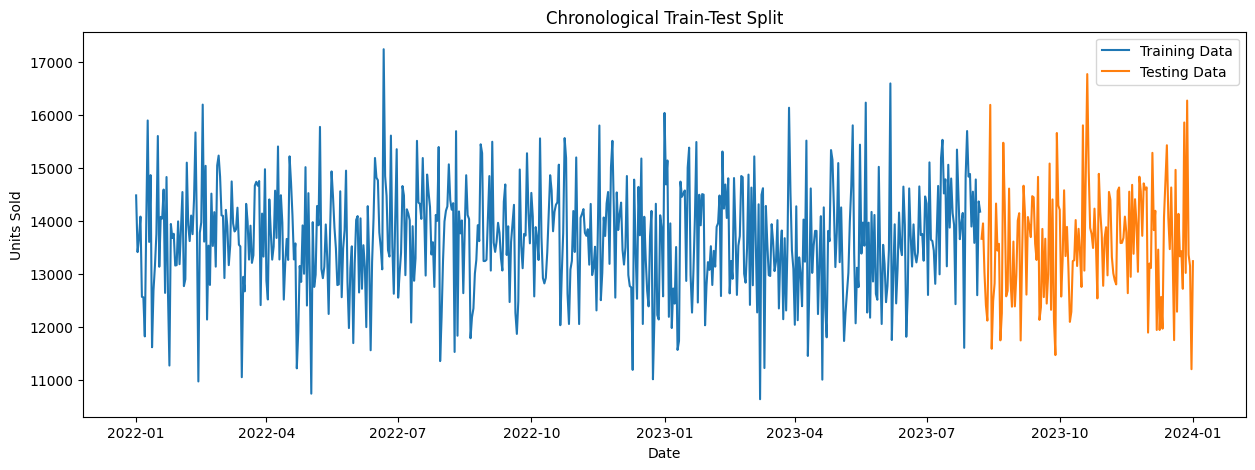

In [8]:
plt.figure(figsize=(15,5))

plt.plot(
    train["Date"],
    train["Units Sold"],
    label="Training Data")

plt.plot(
    test["Date"],
    test["Units Sold"],
    label="Testing Data")

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

## Moving Average Forecast

A Moving Average forecast uses the average of recent observations to estimate future demand.

It serves as a simple baseline forecasting method and provides a reference point for evaluating more advanced forecasting models such as ARIMA.

In [9]:
train = train.copy()

train["Moving Average"] = (
    train["Units Sold"]
    .rolling(window=7)
    .mean())

train.head(10)

,Date,Units Sold,Moving Average
0,2022-01-01,14484,NaN
1,2022-01-02,13415,NaN
2,2022-01-03,13681,NaN
3,2022-01-04,14084,NaN
4,2022-01-05,12572,NaN
5,2022-01-06,12563,NaN
6,2022-01-07,11826,13232.142857
7,2022-01-08,13958,13157.000000
8,2022-01-09,15896,13511.428571
9,2022-01-10,13607,13500.857143


## Visualization of the Moving Average

The following plot compares the original daily sales with the 7-day moving average.

The moving average smooths short-term fluctuations and highlights the overall trend in demand.

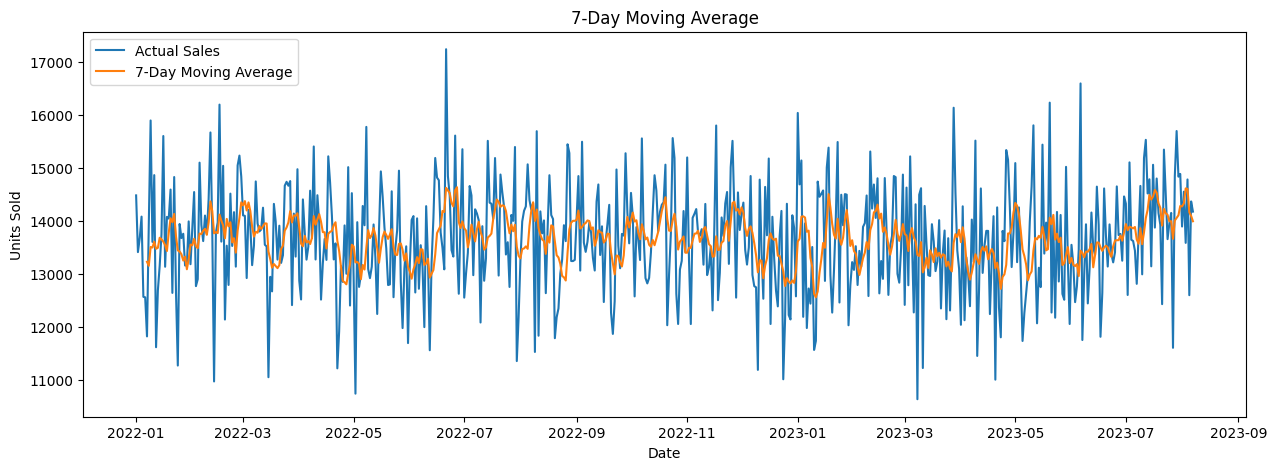

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    train["Date"],
    train["Units Sold"],
    label="Actual Sales"
)

plt.plot(
    train["Date"],
    train["Moving Average"],
    label="7-Day Moving Average"
)

plt.title("7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

## Observation

The moving average smooths daily fluctuations by averaging the previous seven days of sales.

Although it does not capture sudden demand changes, it provides a useful baseline for understanding the overall sales trend before applying more sophisticated forecasting techniques.

## Forecasting the Test Dataset

To evaluate the Moving Average baseline, the average of the last seven observations from the training data is used as the forecast for the testing period.

This provides a simple benchmark against which more advanced forecasting models can be compared.

In [11]:
forecast_value = train["Units Sold"].tail(7).mean()

test = test.copy()

test["Moving Average Forecast"] = forecast_value

test.head()

,Date,Units Sold,Moving Average Forecast
584,2023-08-08,13666,13996.428571
585,2023-08-09,13956,13996.428571
586,2023-08-10,13028,13996.428571
587,2023-08-11,12414,13996.428571
588,2023-08-12,12124,13996.428571


## Visual Comparison

The following plot compares the actual daily sales in the testing period with the Moving Average forecast.

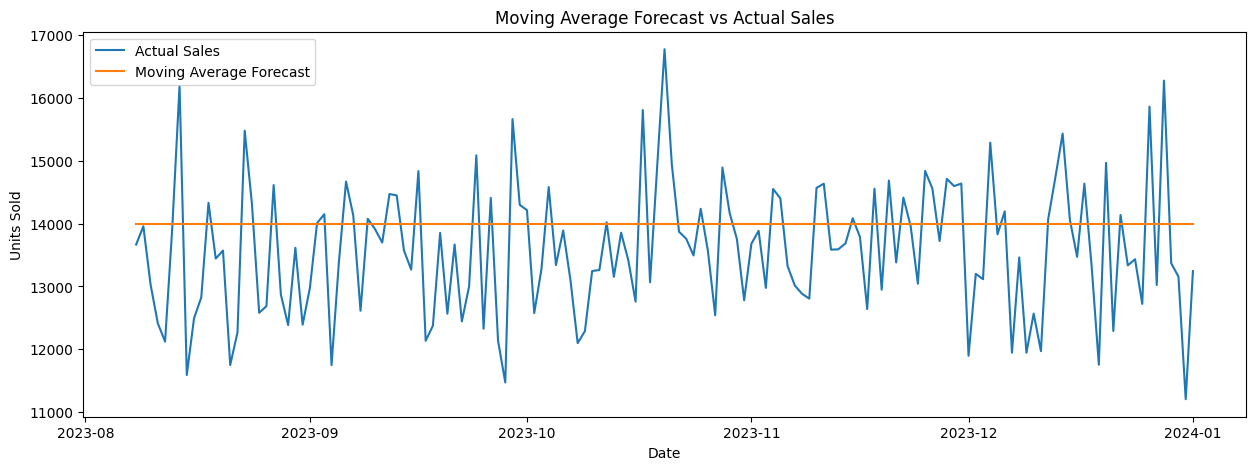

In [12]:
plt.figure(figsize=(15,5))

plt.plot(
    test["Date"],
    test["Units Sold"],
    label="Actual Sales")

plt.plot(
    test["Date"],
    test["Moving Average Forecast"],
    label="Moving Average Forecast")

plt.title("Moving Average Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

## Model Evaluation

The forecasting performance is evaluated using three commonly used regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics measure how closely the forecast matches the actual sales values.

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)

In [14]:
mae = mean_absolute_error(
    test["Units Sold"],
    test["Moving Average Forecast"])

rmse = np.sqrt(
    mean_squared_error(
        test["Units Sold"],
        test["Moving Average Forecast"]))

mape = mean_absolute_percentage_error(
    test["Units Sold"],
    test["Moving Average Forecast"])

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2%}")

MAE  : 907.32
RMSE : 1125.05
MAPE : 6.89%


## Interpretation

The Moving Average model provides a simple baseline forecast for daily sales.

While it smooths fluctuations and is easy to implement, it cannot effectively capture trends or sudden changes in demand.

The evaluation metrics obtained here will serve as a benchmark for comparing the performance of the ARIMA forecasting model in the next section.